In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import pathlib

In [2]:
# Dataset path
DATASET_PATH = pathlib.Path(
    r"D:\PROJECTS\ML_projects\FOD_Project\dataset_grayscale"
)

# Image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Number of classes
NUM_CLASSES = 5

# Random seed
SEED = 42

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "train",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "validation",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "test",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=False
)

Found 2121 files belonging to 5 classes.
Found 439 files belonging to 5 classes.
Found 465 files belonging to 5 classes.


In [4]:
class_names = train_ds.class_names

print("Classes:")
print(class_names)

Classes:
['battery', 'fuelcap', 'pliers', 'screwdrivers', 'sodacan']


In [5]:
for images, labels in train_ds.take(1):
    print("Image batch shape :", images.shape)
    print("Label batch shape :", labels.shape)

Image batch shape : (32, 224, 224, 1)
Label batch shape : (32,)


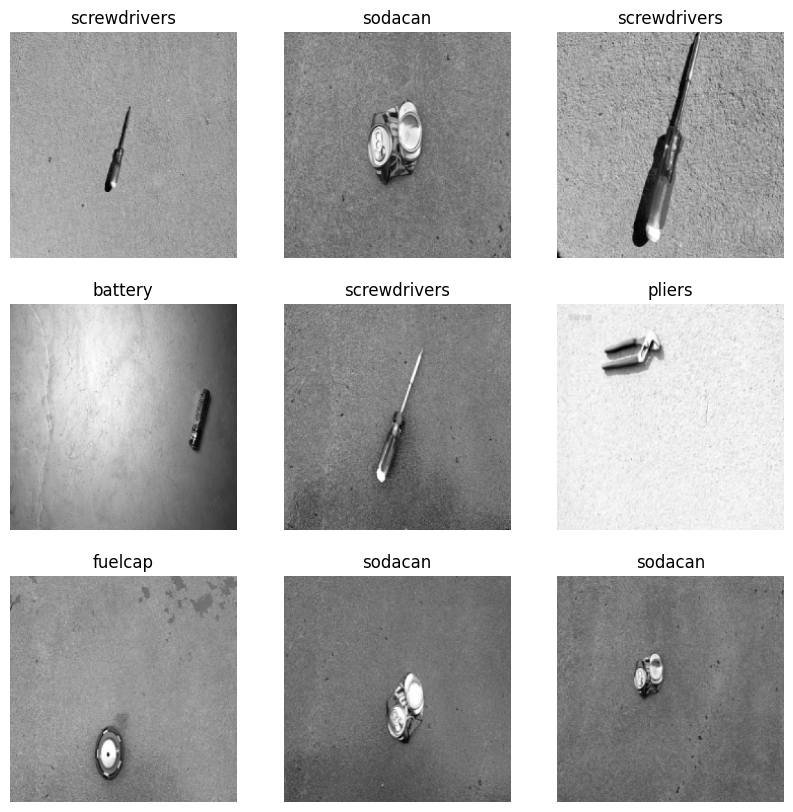

In [6]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8").squeeze(), cmap="gray")
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [7]:
#optimize pipeline

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)

val_ds = val_ds.cache().prefetch(AUTOTUNE)

test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [8]:
# data augmentaion
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.10),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomZoom(0.10)
])

In [9]:
#CNN model
model = keras.Sequential([

    layers.Input(shape=(224, 224, 1)),

    # Data augmentation
    #data_augmentation,

    # Normalize pixel values (0-255 → 0-1)
    layers.Rescaling(1./255),

    # --------------------------
    # Feature Extraction
    # --------------------------

    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    layers.MaxPooling2D(),

    # --------------------------
    # Classification
    # --------------------------

    layers.GlobalAveragePooling2D(),

    layers.Dense(32, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(5, activation='softmax')

    ])

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 224, 224, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 96,965 (378.77 KB)

 Trainable params: 96,965 (378.77 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
#early_stop = tf.keras.callbacks.EarlyStopping(
#    monitor='val_loss',
#    patience=5,
#    restore_best_weights=True
#)

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    #callbacks=[early_stop]
)

Epoch 1/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 25s 346ms/step - accuracy: 0.3074 - loss: 1.5035 - val_accuracy: 0.3349 - val_loss: 1.3102
Epoch 2/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 24s 352ms/step - accuracy: 0.5823 - loss: 1.0395 - val_accuracy: 0.5376 - val_loss: 0.9908
Epoch 3/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 24s 363ms/step - accuracy: 0.6506 - loss: 0.8638 - val_accuracy: 0.4989 - val_loss: 0.9766
Epoch 4/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 24s 355ms/step - accuracy: 0.6775 - loss: 0.8098 - val_accuracy: 0.6310 - val_loss: 0.9767
Epoch 5/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 23s 345ms/step - accuracy: 0.7157 - loss: 0.7178 - val_accuracy: 0.4032 - val_loss: 1.0954
Epoch 6/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 24s 357ms/step - accuracy: 0.7402 - loss: 0.6964 - val_accuracy: 0.5831 - val_loss: 1.2346
Epoch 7/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 23s 349ms/step - accuracy: 0.7440 - loss: 0.6860 - val_accuracy: 0.3850 - val_loss: 1.3955
Epoch 8/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 23s 342ms/step - accuracy: 0.7657 - loss: 0.6256 - val_accu

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = np.concatenate([y for x, y in test_ds], axis=0)

y_pred = model.predict(test_ds)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

print(confusion_matrix(y_true, y_pred))

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step
              precision    recall  f1-score   support

     battery       0.28      0.91      0.43        53
     fuelcap       1.00      0.34      0.51        62
      pliers       1.00      1.00      1.00       126
screwdrivers       0.65      0.97      0.78        97
     sodacan       0.00      0.00      0.00       127

    accuracy                           0.62       465
   macro avg       0.59      0.64      0.54       465
weighted avg       0.57      0.62      0.55       465

[[ 48   0   0   5   0]
 [  0  21   0  41   0]
 [  0   0 126   0   0]
 [  0   0   0  94   3]
 [123   0   0   4   0]]
